In [1]:
import dask
from dask.distributed import Client
from dask.distributed import SSHCluster
from dask.distributed import wait
from dask.distributed import LocalCluster 
from dask.delayed import delayed
import dask.dataframe as dd
import dask.array as da
import dask.bag as d
import graphviz
import pandas as pd
import numpy as np
import itertools
from time import time
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LogLocator
import logging
import seaborn as sns
import os
import json
import psutil
from contextlib import ExitStack


## Functions definition

In [2]:
@dask.delayed
def bites_converter(block): 
    # organize in numpy arrays of 64 bits
    byte_array = np.frombuffer(block, dtype=np.uint64)
    
    # bit masking
    head = (byte_array >> 61) & 0x7         # select bits 61–63 (3 bits) (>> xx rotates bits to the right by xx places)
    fpga = (byte_array >> 58) & 0x7         # select bits 58–60 (3 bits)
    chan = (byte_array >> 49) & 0x1FF       # select bits 49–57 (9 bits)
    orbit = (byte_array >> 17) & 0xFFFFFFFF  # select bits 17–48 (32 bits)
    bx = (byte_array >> 5) & 0xFFF        # select bits 5–16 (12 bits)
    tdc = (byte_array >> 0) & 0x1F         # select bits 0–4 (5 bits)
    
    # we are only interested in data with head==2 
    df = pd.DataFrame(
    {"FPGA": fpga[head==2],
    "CHAN": chan[head==2],
    "ORBIT": orbit[head==2],
    "BX": bx[head==2],
    "TDC": tdc[head==2]} )
    
    return(df)

In [3]:
def read_file(file):

    client_kwargs={
        "endpoint_url": "https://cloud-areapd.pd.infn.it:5210", "verify": False}

    # small is a small bytes object from the start of the first file (to infer format), block is a list of Dask delayed objects, representing chunks of bytes from a file
    small, blocks = dask.bytes.read_bytes(
            file,
            key="32b22133696b4aad9a2872435d392277",
            secret="d2111717321d4f7dbd6755b98e95e713",
            client_kwargs=client_kwargs)  
    
    dfs = [dask.delayed(bites_converter)(block[0]) for block in blocks] # apply converter to each block lazily (each block object is a tuple, so i select [0])
    # converts a list of Dask delayed objects (chunks of a DataFrame) into a unique Dask DataFrame
    ddf = dd.from_delayed(dfs)
    return(ddf)

In [4]:
# This fuction:
# - assigns the chamber number to each event
# - filters events with a single scintillator hit per orbit (in order to be able to identify a unique t_0)
# - consider only events with more than 4 and less than num_hits chamber hits per orbit (4 are usually needed to pass the 4 detector layers, if less it is very likely noise) 
# - calculates relative time between the chamber hits and the scintillator hits to determine the drift time

def first_processing(df,num_hits):
    
    # select scintillator hits
    scintillator = df[(df["FPGA"]==1) & (df["CHAN"]==128)].copy()
    scintillator = scintillator[["ORBIT", "BX", "TDC"]]
    scintillator["t_0"] = 25*(scintillator["ORBIT"]*3564 + scintillator["BX"] + scintillator["TDC"]/30)
    
    # count scintillator hits per ORBIT
    scint_counts = scintillator.groupby("ORBIT").size().to_frame("scint_hits").reset_index()
    # keep only ORBITs with a single scintillator hit
    valid_orbits = scint_counts[scint_counts["scint_hits"] == 1]["ORBIT"]
    
     
    df = df[df["CHAN"]<=127] # remove info about the scintillator from the chamber hits df

    # assign chamber number
    df = df.assign(CHAMBER = -1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] <= 63), 0)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] > 63), 1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] <= 63), 2)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] > 63), 3)

    # scintilattor time offset correction, per chamber
    df = df.assign(time_offset = 0.0)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 0, 95.0-1.1)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 1, 95.0+6.4)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 2, 95.0+0.5)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 3, 95.0-2.6)
    
    df["T_HIT"] = 25*(df["ORBIT"]*3564 + df["BX"] + df["TDC"]/30)
    
    # filter scintillator hits and main df: keep only events with 1 scintillator hit per ORBIT
    scintillator = scintillator[scintillator["ORBIT"].isin(valid_orbits)]
    df = df[df["ORBIT"].isin(valid_orbits)]

    # consider only events with ≤ num_hits chamber hits per ORBIT (avoid overcrowded events)
    chamber_counts = df.groupby("ORBIT").size().to_frame("hits_count").reset_index()
    valid_orbits = chamber_counts[(chamber_counts["hits_count"]<=num_hits)&(chamber_counts["hits_count"]>=4)][["ORBIT"]]
    df = df[df["ORBIT"].isin(valid_orbits["ORBIT"])]

    t0_df = scintillator[["ORBIT", "t_0"]]  # only 1 scint hit per ORBIT guaranteed here
   
    # merge t₀_df with df
    df = df.merge(t0_df, on="ORBIT", how="left") 
    
    # calculate relative chamber hit times wrt to scintillator hit
    df["T_REL"] = df["T_HIT"] - (df["t_0"]-df["time_offset"])
    
    return(df)    

In [5]:
# compute x and z coordinates of the chamber hits (left and right ambiguity for the x coordinate in each hit)

def compute_coordinates(df):
    
    df["x"]=-7.5*42.0 # center of the first cell to the left in each chamber
    df["z"]=0

    # assign the z-position of the center of each chamber w.r.t. to the floor
    df["z"]=df["z"].mask(df["CHAMBER"]==0,219.8)
    df["z"]=df["z"].mask(df["CHAMBER"]==1,977.3)
    df["z"]=df["z"].mask(df["CHAMBER"]==2,1035.6)
    df["z"]=df["z"].mask(df["CHAMBER"]==3,1819.8)

    df["CHAN_LOCAL"] = df["CHAN"]
    df["CHAN_LOCAL"] = df["CHAN_LOCAL"].mask(df["CHAMBER"].isin([1,3]), df["CHAN"]- 64) 

    layer_map = [3, 1, 2, 0]
    df["layer"] = df["CHAN_LOCAL"]%4
    df["layer"] = df["layer"].map({i: layer_map[i] for i in range(4)})

    df["x"]= df["x"] + df["CHAN_LOCAL"]//2 * 21. # cell width: 42mm
    df["z"]= df["z"] - 26.0 + (df["layer"]+0.5)*13. # cell height: 26mm

    df["drift"]= df["T_REL"]*53.8*0.001 # drift velocity 53.8*10 um/ns
    df = df[(df["drift"]>=0)&(df["drift"]<=21.)] # drift can be at most half of the cell, discard other events (meaningless)
    
    df["X_RIGHT"]= df["x"]+df["drift"] 
    df["X_LEFT"]= df["x"]-df["drift"]

    return(df)

In [6]:
def fit_chamber_vectorized(df_ch):
    if len(df_ch) < 3:
        return None
    
    x_left = df_ch["X_LEFT"].values
    x_right = df_ch["X_RIGHT"].values
    z_vals = df_ch["z"].values
    N = len(x_left)

    # generate all left/right combinations (2^N x N)
    choices = np.array(list(itertools.product([0, 1], repeat=N)))
    
    # create candidate x positions for each combination
    x_matrix = np.where(choices == 0, x_left, x_right)  # shape (2^N, N)

    # fit lines and compute residuals in vectorized form
    
    z_matrix = np.tile(z_vals, (2**N, 1))  # repeat z_vals for each combination (2^Nx1 vector)

    # linear regression by hand: x = m*z + q
    z_mean = z_matrix.mean(axis=1)
    x_mean = x_matrix.mean(axis=1)
    m = np.sum((z_matrix - z_mean[:, None]) * (x_matrix - x_mean[:, None]), axis=1) / np.sum((z_matrix - z_mean[:, None])**2, axis=1)
    q = x_mean - m * z_mean
    resid = np.sum((x_matrix - (m[:, None]*z_matrix + q[:, None]))**2, axis=1)
  
    N = z_vals.shape[0]       # number of hits
    ndof = max(N-2, 1)        # degrees of freedom (avoid div by 0)
    chi_sq = resid /ndof

    best_idx = np.argmin(chi_sq)
    best = {
    "m": m[best_idx],
    "q": q[best_idx],
    "χ²/ndof": chi_sq[best_idx],
    "x_best": x_matrix[best_idx],
    "z_vals": z_vals}
    
    return best



def process_partition(df):
    results = []
    for (orbit, chamber_id), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        best = fit_chamber_vectorized(df_grp)
        if best is not None:
            results.append({
                "ORBIT": orbit,
                "CHAMBER": chamber_id,
                "m": best["m"],
                "q": best["q"],
                "χ²/ndof": best["χ²/ndof"],
                "x_best": best["x_best"],
                "z_vals": best["z_vals"]} )
            
    return pd.DataFrame(results)


 # we need to explicitly tell Dask what the output schema of the df will be

meta = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "CHAMBER": pd.Series(dtype="int64"),
    "m": pd.Series(dtype="float64"),
    "q": pd.Series(dtype="float64"),
    "χ²/ndof": pd.Series(dtype="float64"),
    "x_best": pd.Series(dtype="object"),  # lists/arrays stored as objects
    "z_vals": pd.Series(dtype="object")
})
    

In [7]:
def fit_global(df_orbit):
    """
    df_orbit: DataFrame with local fit results for chambers 0,2,3
              and a single ORBIT. It needs to contain columns 'CHAMBER', 'x_best', 'z_vals'. """
    # Consider only chambers 0,2,3
    df_sel = df_orbit[df_orbit["CHAMBER"].isin([0,2,3])]
    if len(df_sel) < 2:
        return None  # troppo poche camere per un fit globale

    # Concatenate all x_best e z_vals of 
    x_all = np.concatenate(df_sel["x_best"].values)
    z_all = np.concatenate(df_sel["z_vals"].values)
    
    # Global linear fit (least squares)
    z_mean = np.mean(z_all)
    x_mean = np.mean(x_all)
    
    m = np.sum((z_all - z_mean)*(x_all - x_mean))/np.sum((z_all - z_mean)**2)
    q = x_mean - m*z_mean
    
    resid = np.sum((x_all - (m*z_all + q))**2)
    ndof = len(x_all)-2
    chi_sq = resid / ndof
    
    return {
        "m_global": m,
        "q_global": q,
        "χ²/ndof_global": chi_sq,
        "x_all": x_all,
        "z_all": z_all
    }

def process_partition_global(df_fit_local):
    results = []
    for orbit, df_grp in df_fit_local.groupby("ORBIT"):
        df_pass = df_grp[["CHAMBER", "x_best", "z_vals"]]
        best_global = fit_global(df_pass)
        if best_global is not None:
            results.append({
                "ORBIT": orbit,
                **best_global })
    return pd.DataFrame(results)

# Schema Dask per il fit globale
meta_global = pd.DataFrame({
    "ORBIT": pd.Series(dtype="int64"),
    "m_global": pd.Series(dtype="float64"),
    "q_global": pd.Series(dtype="float64"),
    "χ²/ndof_global": pd.Series(dtype="float64"),
    "x_all": pd.Series(dtype="object"),
    "z_all": pd.Series(dtype="object")
})

In [8]:
def compute_ang_res(fit_results, global_fit_results, chi2_cut=2.8):
    """
    Compute angular resolution of single chamber comparing the slope of local fit in chamber 2 vs global fit slope
    Apply a cut on the global fit χ²/ndof value to choose which events consider as trust-worthy (default=2.8) """

    fit_results_2 = fit_results[fit_results['CHAMBER'] == 2]

    # merge the local and global fit results on common orbits
    merged = fit_results_2.merge(
    global_fit_results,
    on="ORBIT",
    how="inner")

    compare_results = merged[merged['χ²/ndof_global'] < chi2_cut]

    ang_diff = compare_results.copy()
    ang_diff['ang_diff'] = np.degrees(np.arctan(ang_diff["m"] - ang_diff["m_global"]))
    ang_diff = ang_diff[['ORBIT', 'χ²/ndof_global', 'm', 'm_global', 'ang_diff']]

    # resolution estimate
    ang_res = np.abs(ang_diff['ang_diff']).mean()
    err = ang_diff['ang_diff'].std()/len(ang_diff)**0.5

    return ang_res, err, ang_diff

## Benchmarking 

We consider different combinations for the total number of workers and threads in the cluster and for the number of partitions of the dataset; for each configuration we compute the time needed to persist data in memory after executing each of the different tasks we considered in our project. 

In [1]:
# Return the memory in GiB of the current process
def get_memory_gb():
    process = psutil.Process()
    return process.memory_info().rss / (1024**3)

def benchmark(num_workers, num_threads, num_partitions):
    cluster = SSHCluster(
        ["10.67.22.48", "10.67.22.48", "10.67.22.229", "10.67.22.45"],
        worker_options={"nthreads": num_threads, "n_workers": num_workers, "memory_limit": "auto"},
        scheduler_options={"host": "10.67.22.48", "port": 0, "dashboard_address": "0.0.0.0:8787"},
        connect_options={
            "known_hosts": None,
            "client_keys": "cluster_key"
        }
    )

    client = Client(cluster)

    benchmarking_results = {
        "workers": num_workers,
        "threads": num_threads,
        "partitions": num_partitions
    }

    t_0 = time()
    max_mem_used = 0.0

    with ExitStack() as stack:
        
        df = read_file("s3://project-bkp/data_00000*") 
        df = df.repartition(npartitions=num_partitions)

        # first processing runtime
        start = time()
        new_df = df.map_partitions(first_processing, num_hits=25).persist()
        wait(new_df)
        benchmarking_results["first_processing"] = time() - start
        max_mem_used = max(max_mem_used, get_memory_gb())

        # coordiantes computation runtime
        start = time()
        df_processed = new_df.map_partitions(compute_coordinates).persist()
        wait(df_processed)
        benchmarking_results["hit_coordinates_computation"] = time() - start
        max_mem_used = max(max_mem_used, get_memory_gb())

        # local track fit runtime
        start = time()
        df_local_fit = df_processed.map_partitions(process_partition, meta=meta).persist()
        wait(df_local_fit)
        benchmarking_results["local_fit"] = time() - start
        max_mem_used = max(max_mem_used, get_memory_gb())

        # Global track fit runtime
        start = time()
        df_global_fit = df_local_fit.map_partitions(process_partition_global, meta=meta_global).persist()
        wait(df_global_fit)
        benchmarking_results["global_fit"] = time() - start
        max_mem_used = max(max_mem_used, get_memory_gb())

        # Angular resolution runtime
        start = time()
        _, _, ang_diff = compute_ang_res(df_local_fit, df_global_fit)
        ang_diff = ang_diff.persist()
        wait(ang_diff)
        benchmarking_results["angular_resolution"] = time() - start
        max_mem_used = max(max_mem_used, get_memory_gb())

    benchmarking_results["max_process_mem_GiB"] = max_mem_used
    benchmarking_results["total_wall_time"] = time() - t_0

    client.close()
    cluster.close()

    return benchmarking_results


In [2]:
# this is the number of workers per host! actual number of workers of the cluster is then 3*workers

workers = [1,2,3] 
threads = [1,2,4,8,16] 
partitions = [2,4,8,16,32,64,128,256,512,1024] # with 1 partition the df does not fit in memory, so computation is impossible

# create a json file for each configuration
os.makedirs("Benchmarking",exist_ok=True)

for num_workers in workers:
    for num_threads in threads:
        for num_partitions in partitions:
            print(f"Performing benchmarking with {num_workers} workers, {num_threads} threads, {num_partitions} partitions")
            filename= f"Benchmarking/results_{num_workers}workers_{num_threads}threads_{num_partitions}partitions.json" 
             # skip that computation if file already exists
            if os.path.exists(filename):
                print(f"Skipping {filename}, already exists \n")
                continue
            try:
             res = benchmark(num_workers,num_threads,num_partitions)
            except Exception as e:
                print(f"Error with the combination workers={num_workers}, threads={num_threads}, partitions={num_partitions}: {e}\n")
                continue 
                
            with open(filename,'w') as file:
                json.dump(res,file) # store in files not to lose partial results in case of problems during the cycle
            print(f"Total wall time {res['total_wall_time']} s","\n")

Performing benchmarking with 1 workers, 1 threads, 2 partitions
Skipping Benchmarking/results_1workers_1threads_2partitions.json, already exists 

Performing benchmarking with 1 workers, 1 threads, 4 partitions
Skipping Benchmarking/results_1workers_1threads_4partitions.json, already exists 

Performing benchmarking with 1 workers, 1 threads, 8 partitions
Skipping Benchmarking/results_1workers_1threads_8partitions.json, already exists 

Performing benchmarking with 1 workers, 1 threads, 16 partitions
Skipping Benchmarking/results_1workers_1threads_16partitions.json, already exists 

Performing benchmarking with 1 workers, 1 threads, 32 partitions
Skipping Benchmarking/results_1workers_1threads_32partitions.json, already exists 

Performing benchmarking with 1 workers, 1 threads, 64 partitions
Skipping Benchmarking/results_1workers_1threads_64partitions.json, already exists 

Performing benchmarking with 1 workers, 1 threads, 128 partitions
Skipping Benchmarking/results_1workers_1thread

In [3]:
# create a dataframe with benchmarking results from the files 
benchmarking_results=[]

for worker in workers:
    for thread in threads:
        for parts in partitions:
            filename= f"Benchmarking/results_{worker}workers_{thread}threads_{parts}partitions.json" 
            if os.path.exists(filename):
                with open(filename,'r') as file:
                    res= json.load(file)
                    res["cluster_workers"] = 3*worker
                    benchmarking_results.append(res)
            else:
                continue
         
benchmarking_results= pd.DataFrame(benchmarking_results)
benchmarking_results["total_threads"]= benchmarking_results["cluster_workers"]*benchmarking_results["threads"]
benchmarking_results.head(10)

,workers,threads,partitions,first_processing,hit_coordinates_computation,local_fit,global_fit,angular_resolution,max_process_mem_GiB,total_wall_time,cluster_workers,total_threads
0,1,1,2,4.749794,0.059868,3.795048,4.216158,0.348075,0.308941,16.532262,3,3
1,1,1,4,3.956102,0.079423,3.658985,3.901227,0.565053,0.317642,14.231436,3,3
2,1,1,8,4.501268,0.129345,3.846549,4.411410,0.920496,0.319714,15.921607,3,3
3,1,1,16,4.182687,0.216861,3.923966,4.063900,1.763361,0.319962,16.370963,3,3
4,1,1,32,5.038970,0.425097,3.686666,4.065192,3.724895,0.320923,18.897633,3,3
5,1,1,64,5.527180,0.786863,3.966648,4.395025,6.845650,0.320911,23.443079,3,3
6,1,1,128,6.672618,1.439157,4.241772,4.724375,13.111257,0.321884,32.028076,3,3
7,1,1,256,8.132335,3.015949,5.459104,5.861824,26.639055,0.324066,51.040854,3,3
8,1,1,512,13.043519,5.716938,7.141596,7.342285,49.251666,0.327164,84.490199,3,3
9,1,1,1024,21.470325,11.602828,9.918417,9.968347,87.328202,0.332825,142.144037,3,3


# Analysis of the results

In [4]:
# 3-D colormap plot: we try to give a first visual represenattion of the dependency from all the parameters 

def three_d_plot(df,section):

    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection="3d")
    
    
    min_val = benchmarking_results[section].min()
    max_val = benchmarking_results[section].max()
    
    
    sc = ax.scatter(
        benchmarking_results["cluster_workers"],
        np.log2(benchmarking_results["partitions"]),
          benchmarking_results["threads"],
        c=benchmarking_results[section],
        cmap="RdYlBu_r", norm=matplotlib.colors.LogNorm(vmin=min_val,vmax=max_val),
        s=60,alpha=1., edgecolors='black'
    )
    
    ax.set_xlabel("Cluster Workers",fontsize=13)
    ax.set_ylabel("Partitions (log2 scale)",fontsize=13)
    ax.set_zlabel("Threads per worker",fontsize=13)
    
    
    cbar = fig.colorbar(sc, ax=ax, shrink=0.95,pad=0.05)
    cbar.set_label("Runtime (s)",fontsize=13)
    
    ticks = np.logspace(np.floor(np.log10(min_val)), np.ceil(np.log10(max_val)), num=10)
    ticks = ticks[(ticks >= min_val) & (ticks <= max_val)]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])
    
    plt.show()
    
    return

In [16]:
# here we fix the number of threads and study how the computation time sclaes with the total number of workers and partitions

def heatmap_fixed_threads(df, section_col, fixed_threads, log=True, title=None):

    df = df[df['threads'] == fixed_threads]

    if df.empty:
        raise ValueError(f"Nessun dato trovato per threads={fixed_threads}")

    min_val = df[section_col].min()
    max_val = df[section_col].max()

    heatmap_data = df.pivot(
        index="partitions",       # y-axis
        columns="cluster_workers", # x-axis
        values=section_col         # color scale
    )

    fig, ax = plt.subplots(figsize=(10, 6))  

    if log:
        norm = matplotlib.colors.LogNorm(vmin=min_val, vmax=max_val)
    else:
        norm = matplotlib.colors.Normalize(vmin=min_val, vmax=max_val)

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="cividis",
        norm=norm,
        ax=ax
    )

    cbar = ax.collections[0].colorbar
    if log:
        ticks = np.logspace(np.floor(np.log10(min_val)), np.ceil(np.log10(max_val)), num=5)
    else:
        ticks = np.linspace(min_val, max_val, num=5)

    ticks = ticks[(ticks >= min_val) & (ticks <= max_val)]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])

    if title is None:
        ax.set_title(f"Heatmap of {section_col} with {fixed_threads} threads/worker")
    else:
        ax.set_title(title)

    ax.set_ylabel("Number of Partitions", fontsize=13)
    ax.set_xlabel("Cluster Workers", fontsize=13)

    plt.show() 
    
    return

In [20]:
# a crucial parameter is the total number of threads in the cluster (we average the runtimes of the diff combinations of total workers x threads giving the same product)

def heatmap_total_threads(df, section_col, log=True, title=None):
    heatmap_data = df.groupby(["partitions", "total_threads"])[section_col].mean().unstack()

    min_val = df[section_col].min()
    max_val = df[section_col].max()

    fig, ax = plt.subplots(figsize=(10, 6))   

    if log:
        norm = matplotlib.colors.LogNorm(vmin=min_val, vmax=max_val)
    else:
        norm = matplotlib.colors.Normalize(vmin=min_val, vmax=max_val)

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="cividis",
        norm=norm,
        ax=ax
    )

    cbar = ax.collections[0].colorbar
    if log:
        ticks = np.logspace(np.floor(np.log10(min_val)), np.ceil(np.log10(max_val)), num=5)
    else:
        ticks = np.linspace(min_val, max_val, num=5)

    ticks = ticks[(ticks >= min_val) & (ticks <= max_val)]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in ticks])

    if title is None:
        ax.set_title(f"Heatmap of {section_col} vs Total Threads", fontsize=14)
    else:
        ax.set_title(title, fontsize=14)

    ax.set_ylabel("Number of Partitions", fontsize=13)
    ax.set_xlabel("Total Threads in Cluster", fontsize=13)

    plt.tight_layout()
    plt.show()

    return

In the following we examine separately the results of the benchmarking for the different sections of the project and for the overall computation time. 

## Pre-processing of the whole data

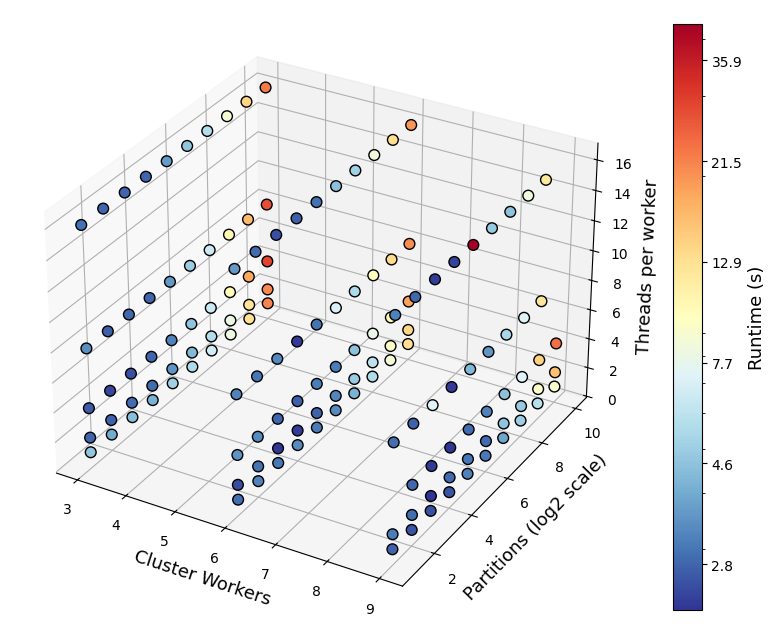

In [7]:
three_d_plot(benchmarking_results,"first_processing")

The first thing that we notice is that runtime greatly increases defining too many partitions of the dataset. We can also spot some improvements with a total number of workers greater than 3. The number of threads per worker does not show a very clear correlation per se with the runtime.

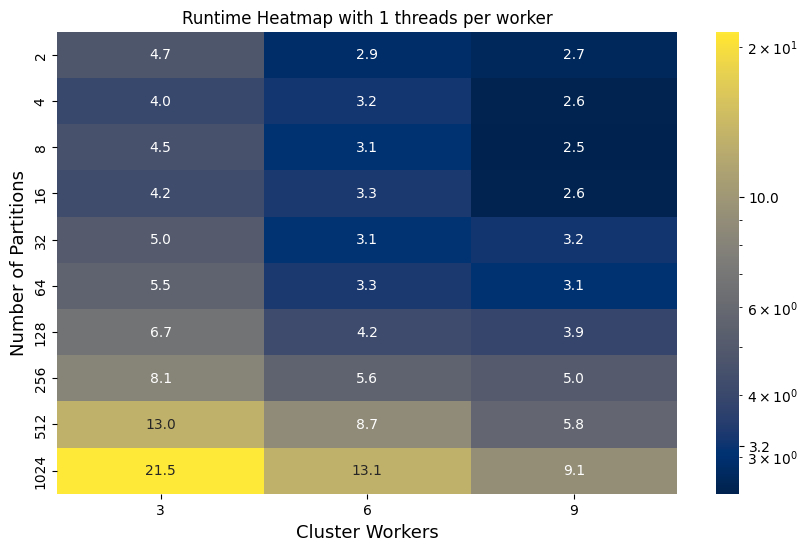

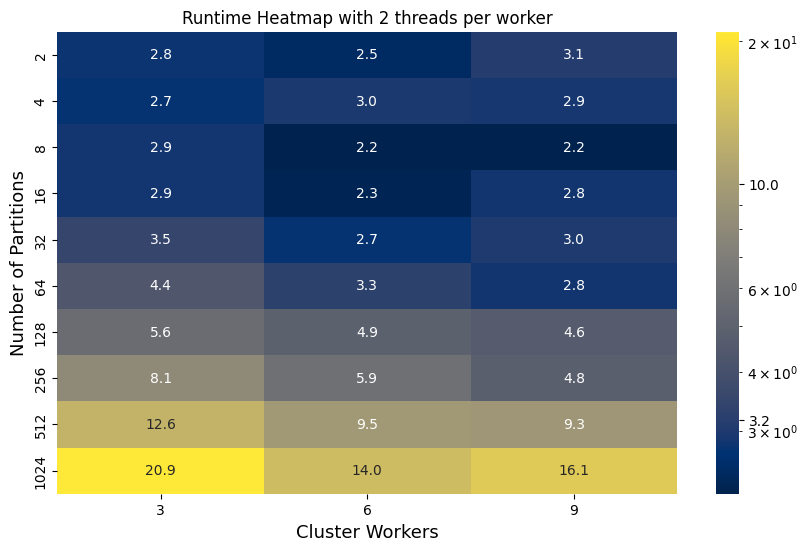

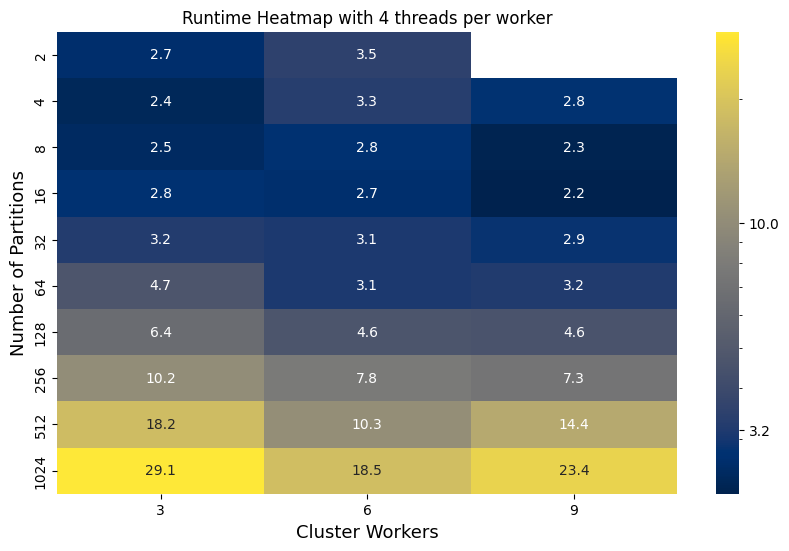

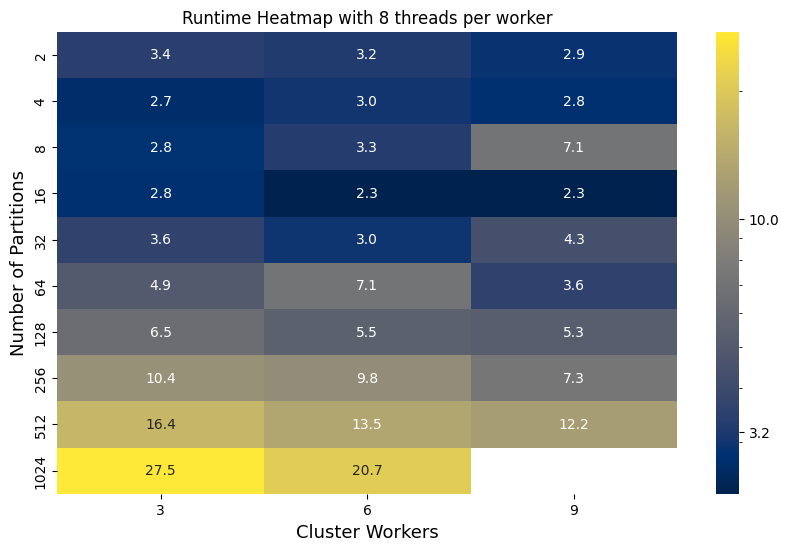

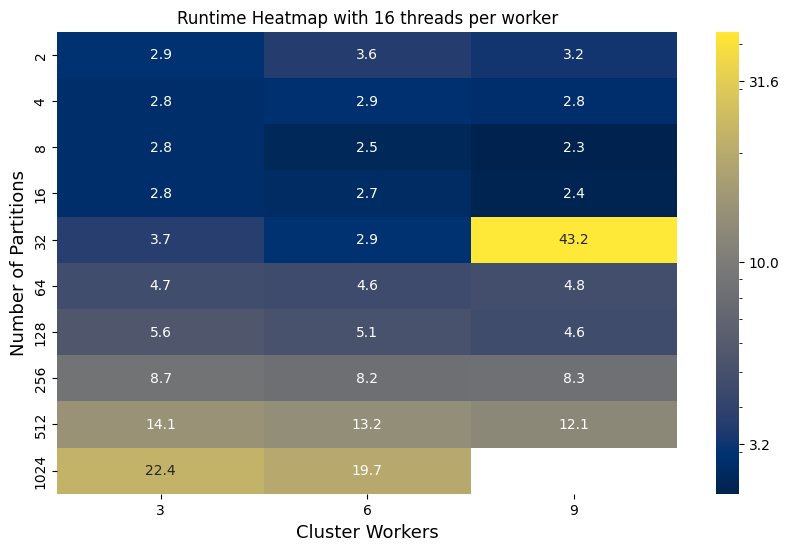

In [11]:
for thread in threads: 
    title = f"Runtime Heatmap with {thread} threads per worker"
    heatmap_fixed_threads(benchmarking_results, "first_processing", fixed_threads=thread, log=True, title = title)
    print("\n")

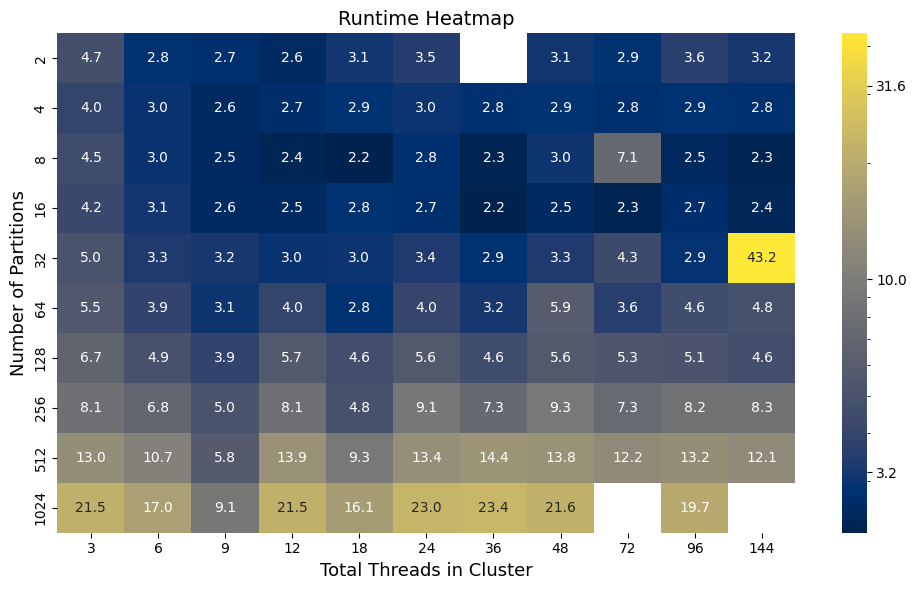

In [9]:
title = "Runtime Heatmap"
heatmap_total_threads(benchmarking_results, "first_processing", title=title)

The best results are obtained with a number of partitions between 8-16 and for a total number of threads in a wide range above 9.   

## Local track Fit

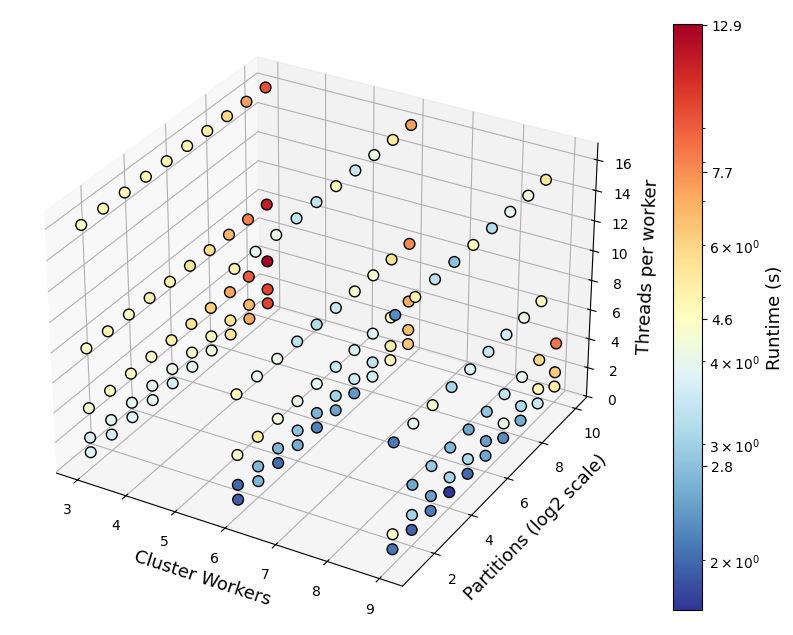

In [10]:
three_d_plot(benchmarking_results,"local_fit")

For this task, we can clearly improve the computation speed by increasing the number of workers in the cluster while limiting the number of threads per worker and the number of partitions.   

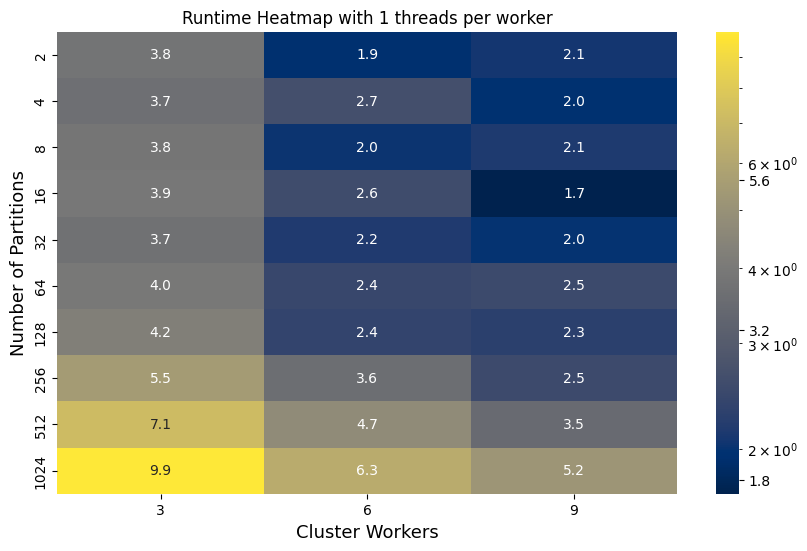

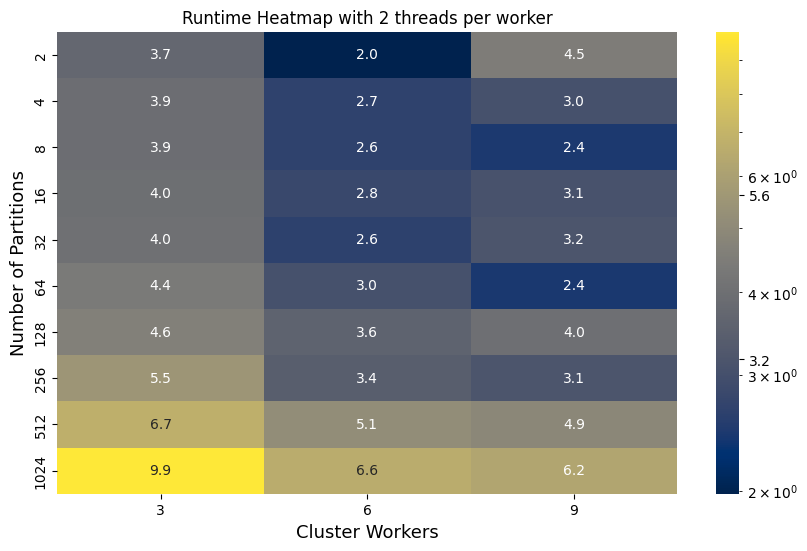

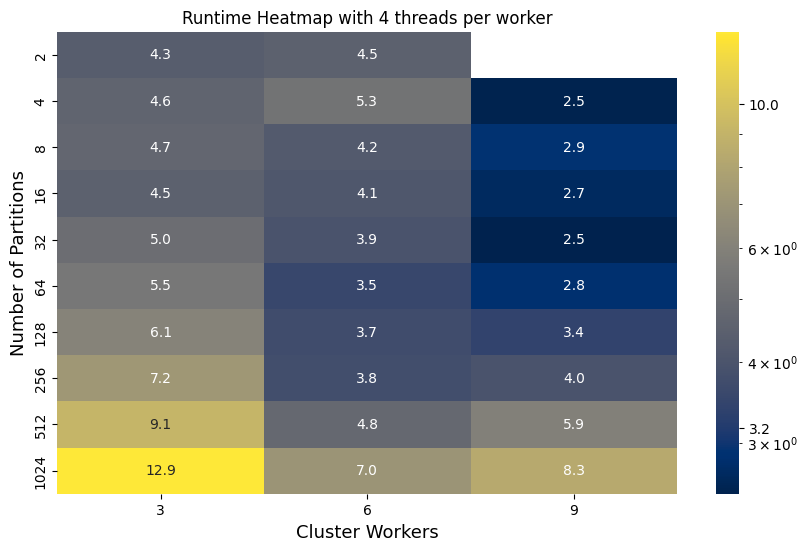

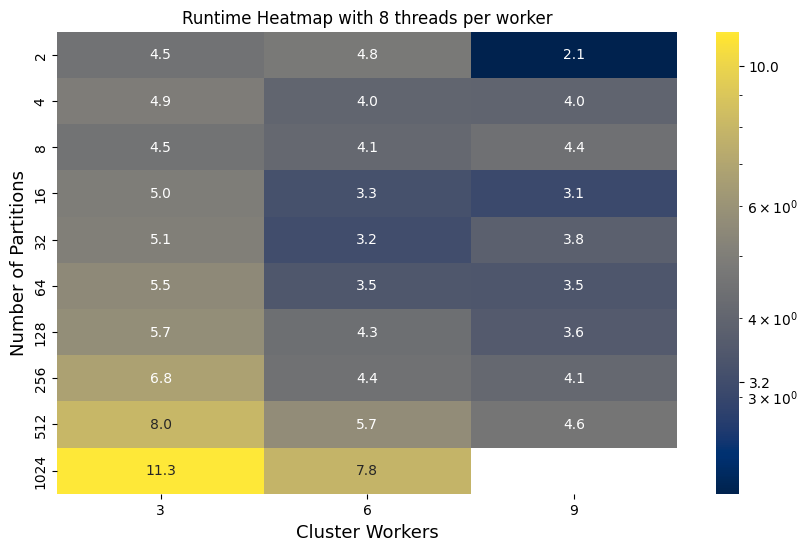

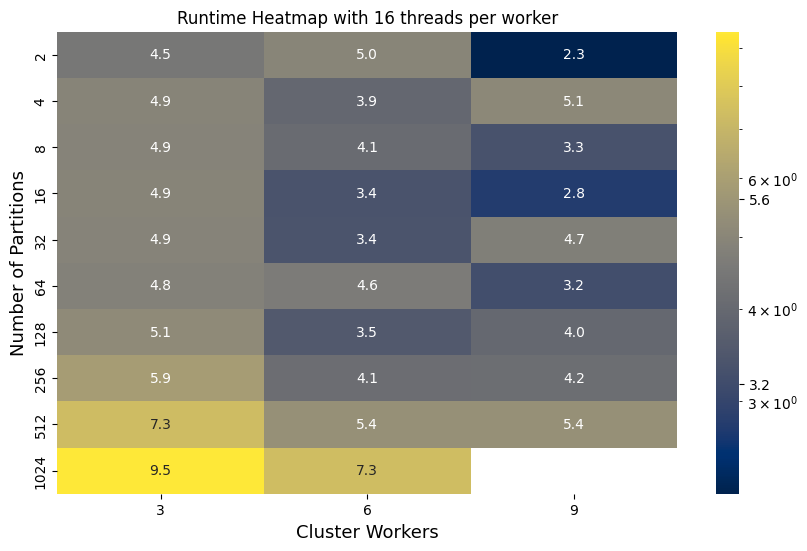

In [11]:
for thread in threads: 
    title = f"Runtime Heatmap with {thread} threads per worker"
    heatmap_fixed_threads(benchmarking_results, "local_fit", fixed_threads=thread, log=True, title = title)
    print("\n")

It is clear how performances get generally worse as the number of threads per worker increases. The best choice is to consider 6-9 workers with a single thread and few partitions (< 32) of the dataset.

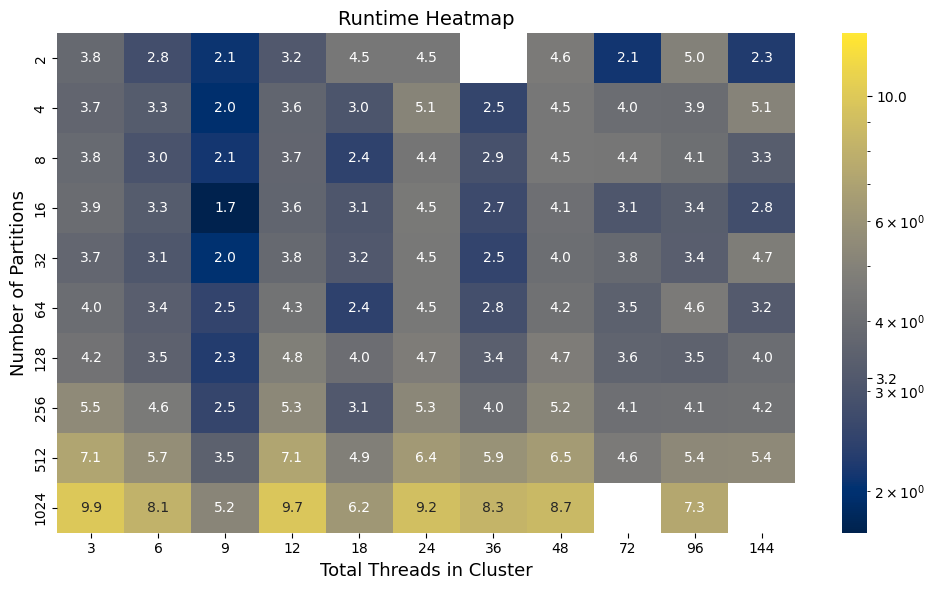

In [12]:
title = "Runtime Heatmap"
heatmap_total_threads(benchmarking_results, "local_fit", title=title)

## Global track Fit

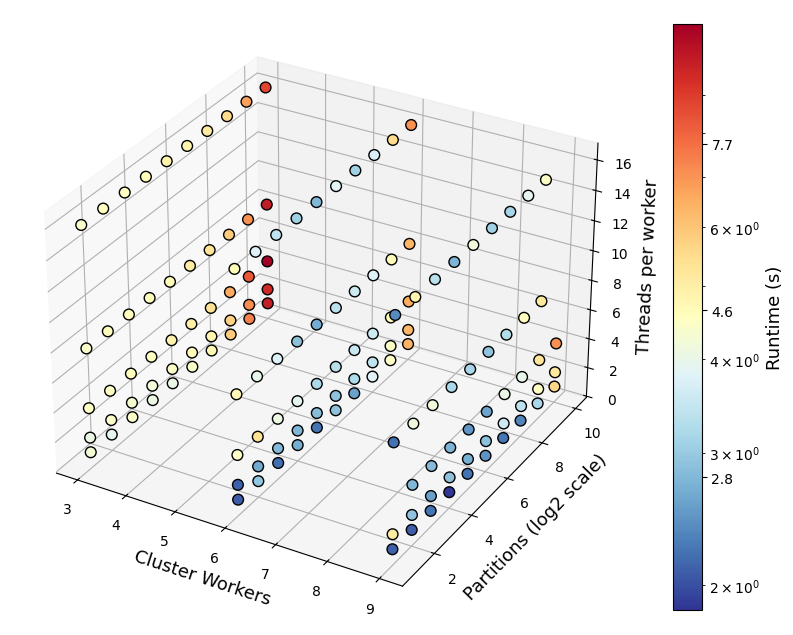

In [13]:
three_d_plot(benchmarking_results,"global_fit")

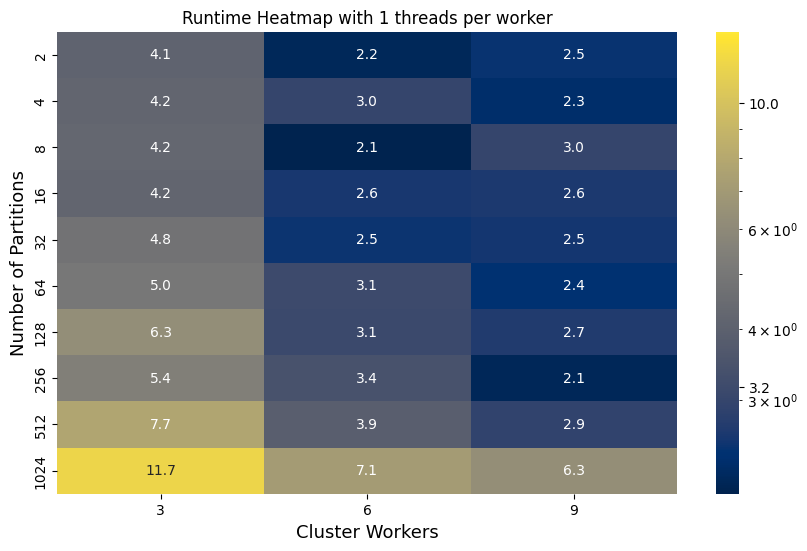

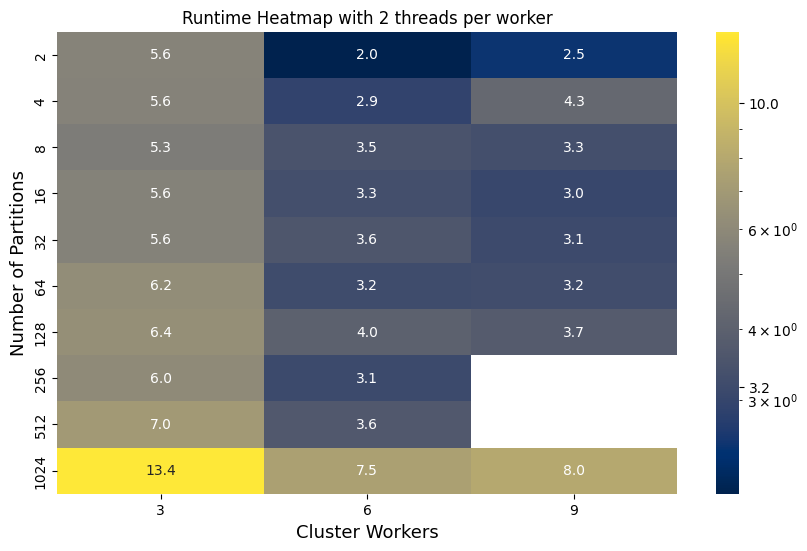

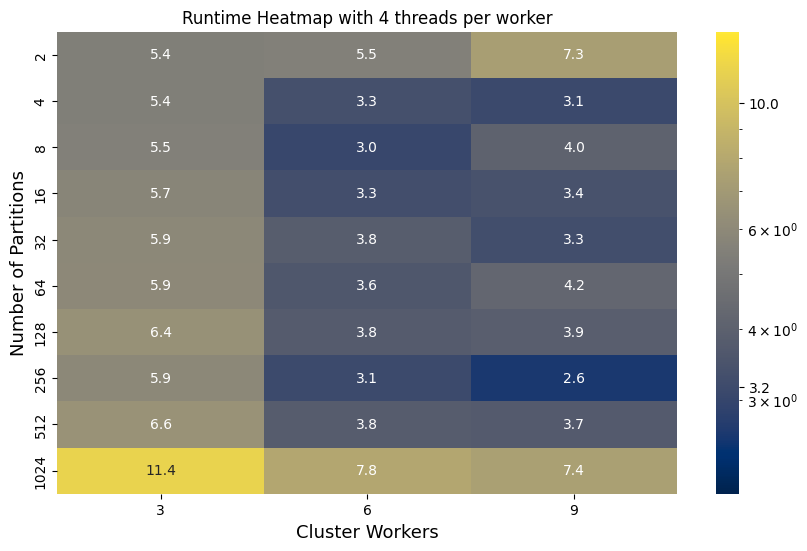

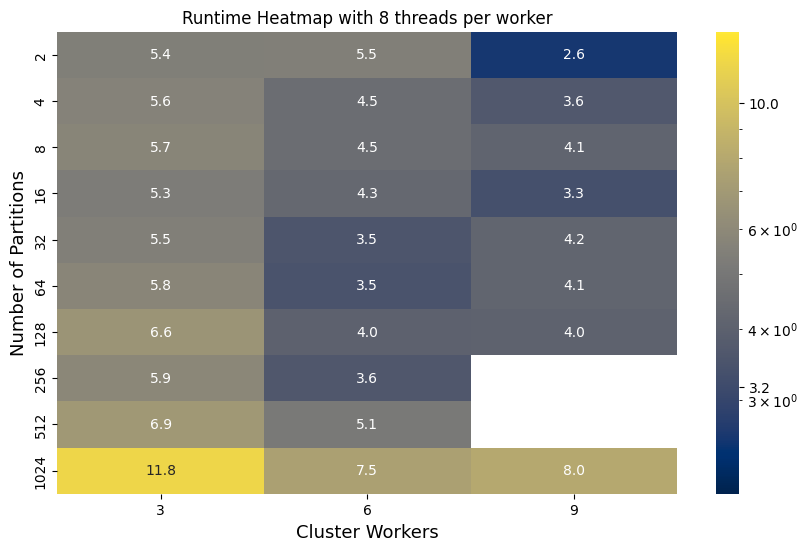

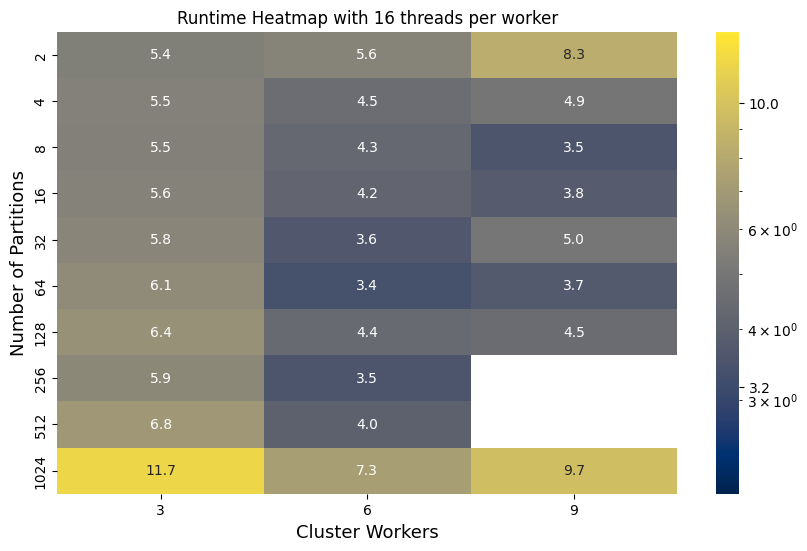

In [42]:
for thread in threads: 
    title = f"Runtime Heatmap with {thread} threads per worker"
    heatmap_fixed_threads(benchmarking_results, "global_fit", fixed_threads=thread, log=True, title = title)
    print("\n")

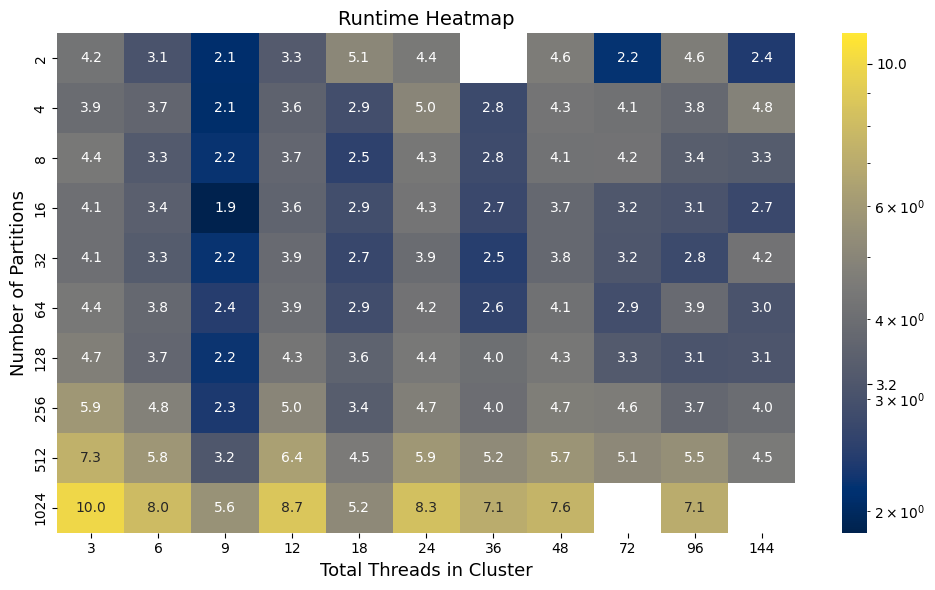

In [14]:
title = "Runtime Heatmap"
heatmap_total_threads(benchmarking_results, "global_fit", title=title)

We get very similar results and analogue considerations as for the local fit.  

## Angular resolution

Since the dataframe to handle is very small, we expect that the best choice is to perform a local computation (worse results with more workers and partitions).  

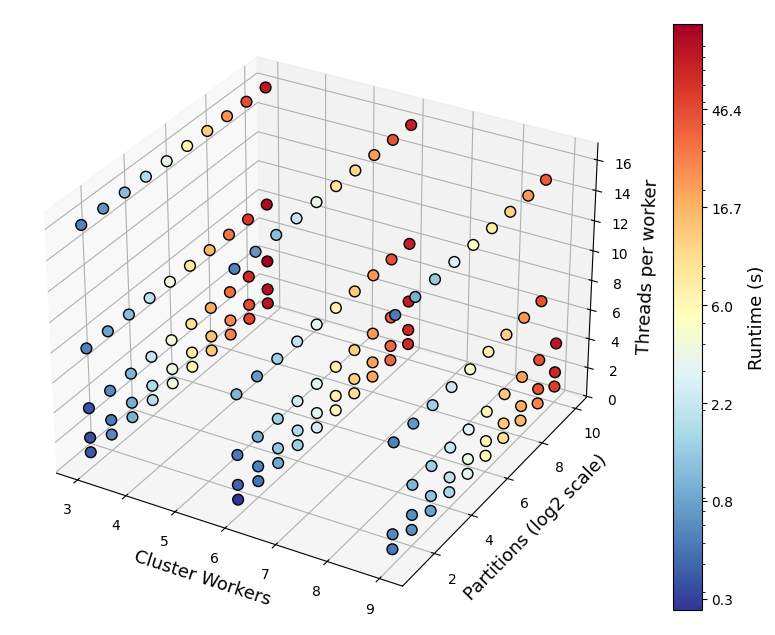

In [15]:
three_d_plot(benchmarking_results,"angular_resolution")

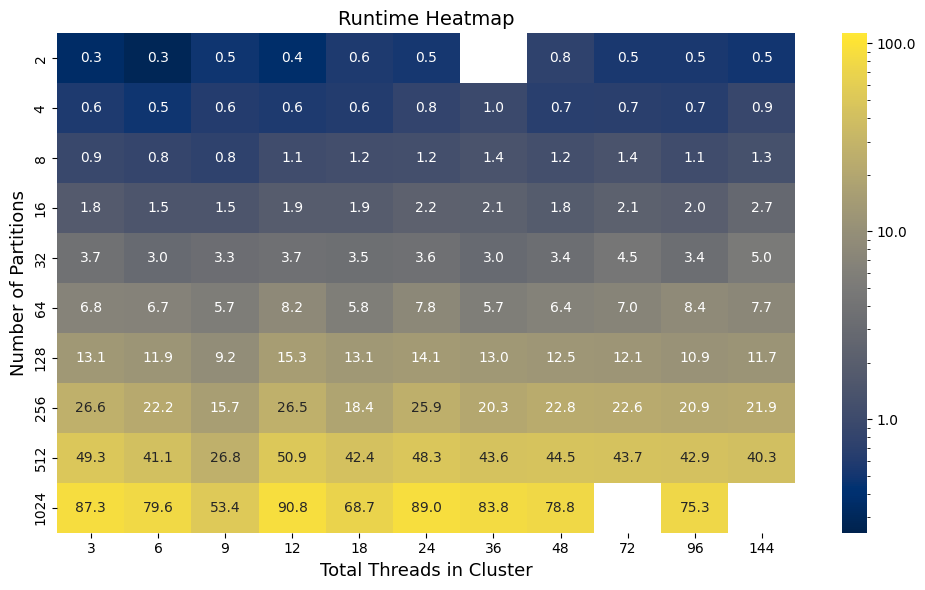

In [16]:
title = "Runtime Heatmap"
heatmap_total_threads(benchmarking_results, "angular_resolution", title=title)

As expected, the higher the number of partitions defined, the longer the computation takes.

## Total wall time

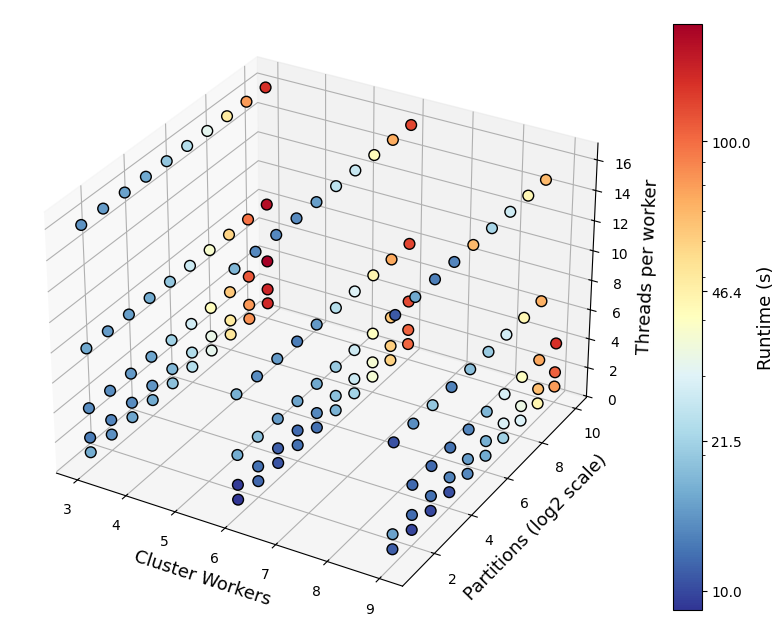

In [17]:
three_d_plot(benchmarking_results,"total_wall_time")

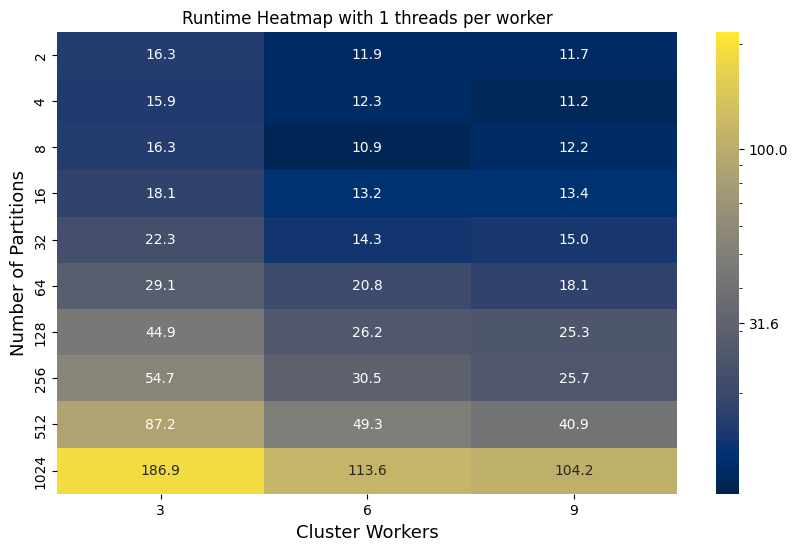

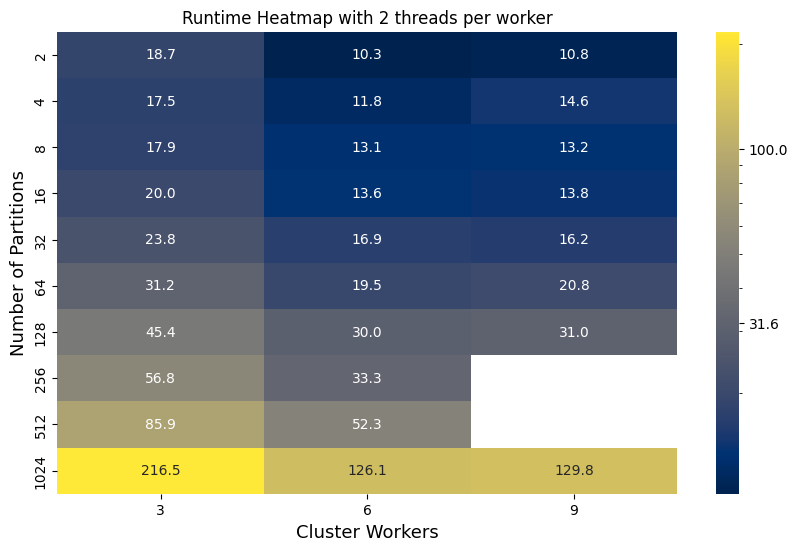

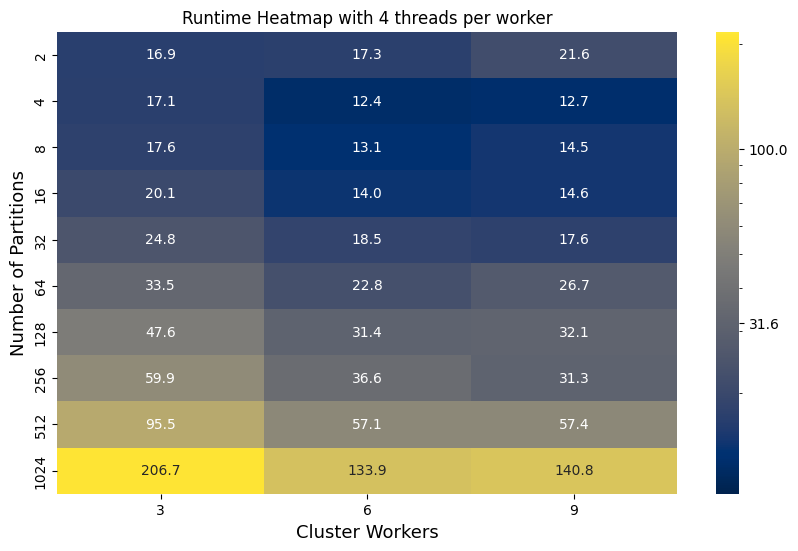

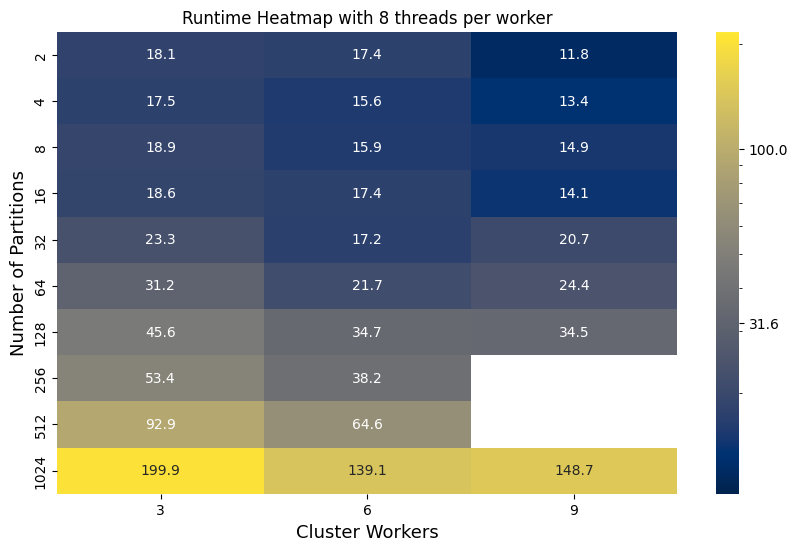

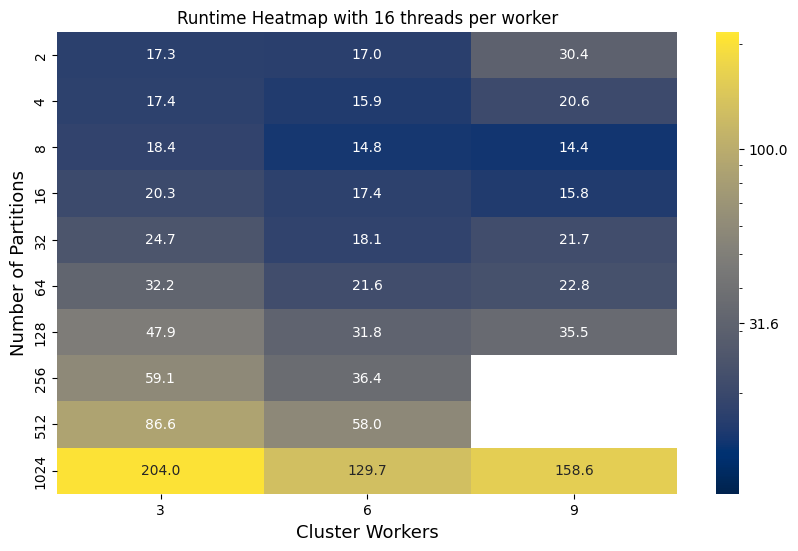

In [46]:
for thread in threads: 
    title = f"Runtime Heatmap with {thread} threads per worker"
    heatmap_fixed_threads(benchmarking_results, "total_wall_time", fixed_threads=thread, log=True, title = title)
    print("\n")

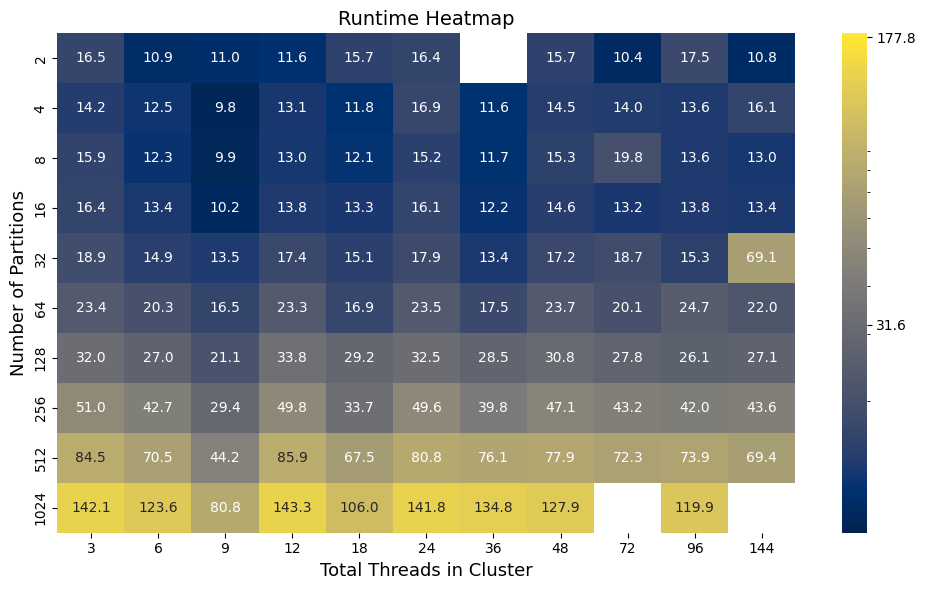

In [18]:
title = "Runtime Heatmap"
heatmap_total_threads(benchmarking_results, "total_wall_time", title=title)

The best overall compromise appears to be achieved with a higher number of workers (6-9), a limited number of threads per worker (1-2) and of partitions of the dataset (4-16).
Nonethelesss, performance remains comparable/acceptable across a wide range for the total number of processes in the cluster, provided the number of partitions is kept limited to less than around 16. Among all parameters, the number of partitions emerges as the most influential factor for cluster performance.

## Process Memory

Here we investigate the memory used to execute the intire pipeline, focusing on the peak memory usage across all workers in the networks. This could be useful in identifying inefficiencies or potential bottlenecks.

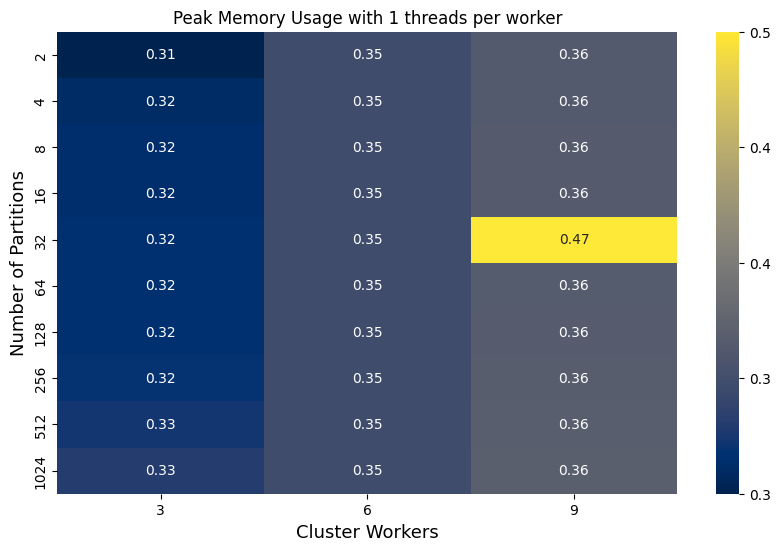

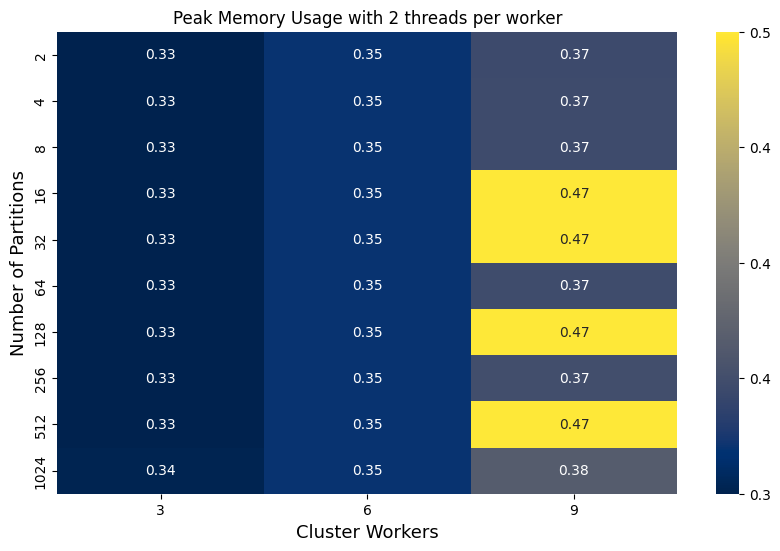

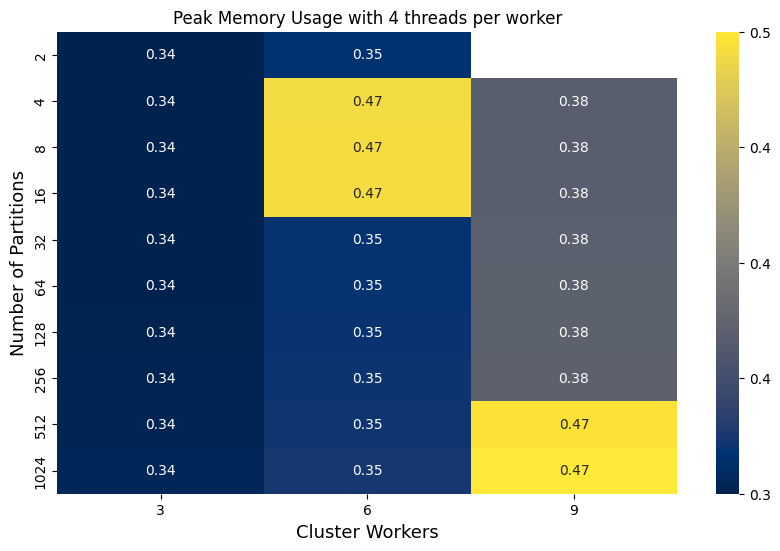

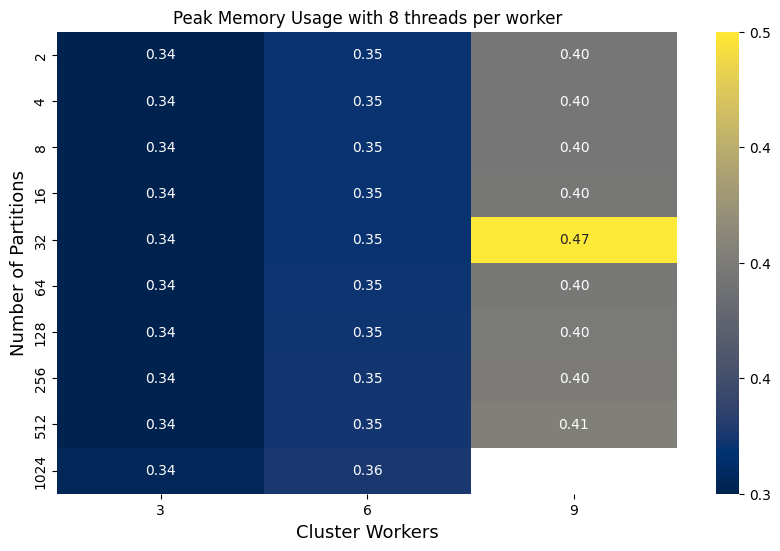

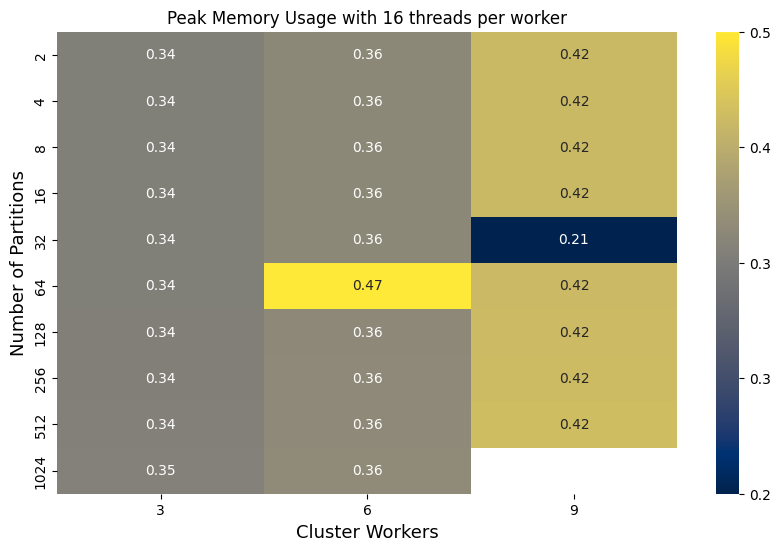

In [18]:
for thread in threads:
    heatmap_fixed_threads(
        benchmarking_results, 
        "max_process_mem_GiB", 
        fixed_threads=thread, 
        log=False, 
        title = f"Peak Memory Usage with {thread} threads per worker"
    )
    print("\n")

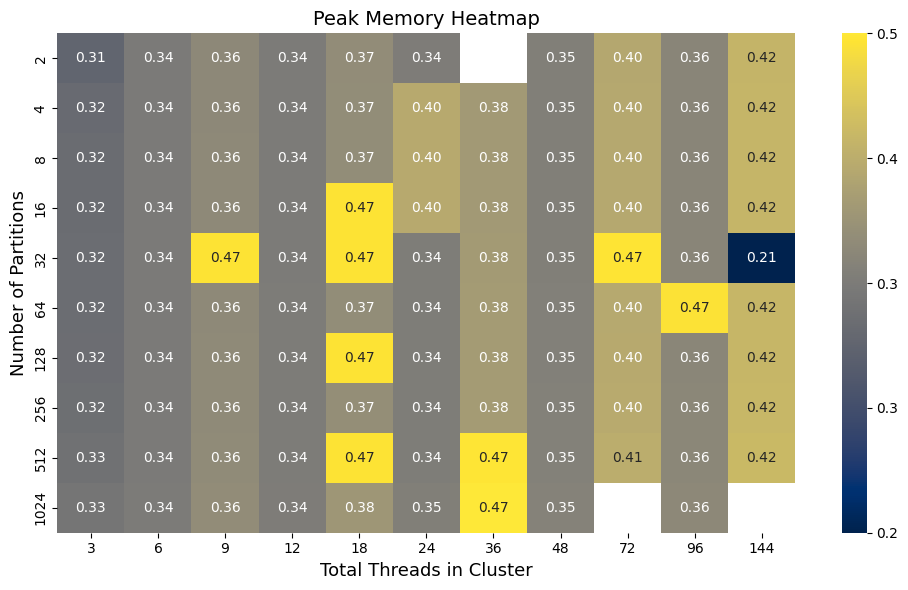

In [21]:
heatmap_total_threads(
    benchmarking_results,
    "max_process_mem_GiB",
    log=False,
    title="Peak Memory Heatmap"
)

We can see that the overall peaks are around 0.3 GiB, with an increase when using 18 threads and a relatively large number of partitions. The peak memory tends to be smaller with fewer threads (3-6), regardless of the number of partitions.

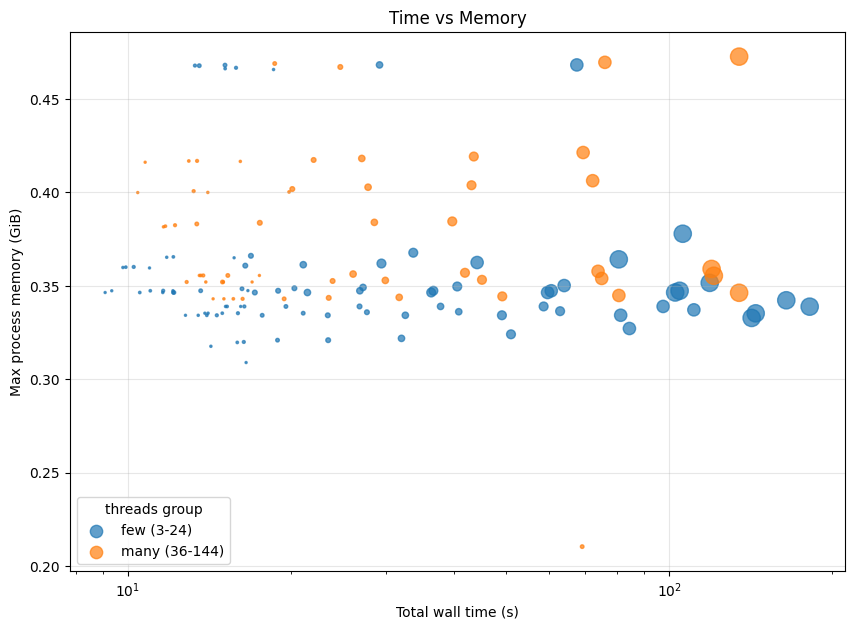

In [29]:
# definition of a threshold for grouping the threads

def threads_bucket(p):
    if p <= 24:
        return "few (3-24)"
    else:
        return "many (36-144)"

benchmarking_results["threads_group"] = benchmarking_results["total_threads"].apply(threads_bucket)

plt.figure(figsize=(10,7))
for group, data in benchmarking_results.groupby("threads_group"):
    plt.scatter(
        data["total_wall_time"],
        data["max_process_mem_GiB"],
        s=2.+data["partitions"]*0.15,
        alpha=0.7,
        label=group
    )

plt.xscale("log")
plt.xlabel("Total wall time (s)")
plt.ylabel("Max process memory (GiB)")
plt.title("Time vs Memory")
plt.legend(title="threads group")
plt.grid(True, alpha=0.3)
plt.show()

Here the marker size represents the number of partitions used in the computation.
<br>
Configurations with a large number of total threads (orange) tend to have peak memory around $0.40$ GiB, while those with fewer number of threads (blue) show peaks more clustered around $0.35$ GiB. Overall, we can conclude that memory usage is relatively stable, with peaks fluctuating within a narrow band ($\textasciitilde 0.3 – 0.45$ GiB).
<br>
We can also notice that larger partitions (bigger markers) tend to appear in the longer time region. This reflects the fact that too many small partitions cause a very high overhead reducing parallelization efficiency.